<a href="https://colab.research.google.com/github/rudrakshagrawal60-netizen/Data_Engineering_FinOps_and_SLA_Prediction/blob/main/Data_Engineering_FinOps_and_SLA_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install fastparquet or pyarrow if not already available in Colab
!pip install pyarrow fastparquet -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options to view more columns
pd.set_option('display.max_columns', None)
print("Libraries imported successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 29.6 MB/s eta 0:00:00
Libraries imported successfully!


In [ ]:
# Updated path variables (matching the exact uploaded names)
telemetry_path = '/content/pipeline_execution_telemetry[1].parquet'
survey_path = '/content/data_engineering_compensation_and_stack_survey[1].parquet'
master_path = '/content/data_engineering_ai_pipelines[1].parquet'

# DataFrames load karein
df_telemetry = pd.read_parquet(telemetry_path)
df_survey = pd.read_parquet(survey_path)
df_master = pd.read_parquet(master_path)

print(f"Telemetry Records: {df_telemetry.shape}")
print(f"Survey Records: {df_survey.shape}")
print(f"Master Records: {df_master.shape}")

Telemetry Records: (150000, 24)
Survey Records: (50000, 19)
Master Records: (50000, 31)


In [ ]:
# Master DataFrame ka preview dekhna
print("--- Master Dataset Head ---")
display(df_master.head())

# Datatypes aur missing values check karna
print("\n--- Master Dataset Info ---")
df_master.info()

# Basic statistics check karna (jaise average salary, average cost etc.)
print("\n--- Basic Statistics ---")
display(df_master.describe())

--- Master Dataset Head ---


,response_id,job_role,company_tier,years_of_experience,country,remote_policy,base_salary_usd,annual_equity_usd,annual_bonus_usd,total_compensation_usd,primary_cloud,orchestrator,data_warehouse,lakehouse_table_format,has_production_rag,vector_database,mlops_maturity_level,data_quality_framework,primary_language,record_id,submission_date,work_location,daily_volume_gb,avg_pipeline_duration_min,monthly_failure_rate_pct,salary_usd,tool,latency_ms,failure_rate,uptime_pct,ml_enabled
0,SURV-000000,Data Engineer,Pre-IPO Unicorn / Scaleup,18,United States,100% Remote,259852,72996,74200,407048,Google Cloud,Argo Workflows,DuckDB,Apache Iceberg,False,None,1,None,Go,PIPE-100000,2025-11-30,United States,44.2,158,0.20,407048,Argo Workflows,9480000,0.0020,99.80,0
1,SURV-000001,MLOps / AI Platform Engineer,FinTech / High-Frequency Trading,23,Australia,Hybrid (2-3 days office),456250,271364,255399,983013,AWS,Databricks Workflows,ClickHouse,Apache Iceberg,True,Pinecone,4,dbt Tests,Python,PIPE-100001,2025-03-28,Australia,96.4,175,0.55,983013,Databricks Workflows,10500000,0.0055,99.45,1
2,SURV-000002,Senior Data Engineer,FinTech / High-Frequency Trading,21,Israel,Hybrid (2-3 days office),470410,246248,561257,1277915,AWS,Prefect,Redshift,Apache Iceberg,True,Milvus,4,Soda Core,Python,PIPE-100002,2025-07-10,Israel,41.4,67,0.20,1277915,Prefect,4020000,0.0020,99.80,1
3,SURV-000003,Lead / Staff Data Engineer,FinTech / High-Frequency Trading,10,Japan,Full On-Site,336551,103648,127020,567219,Azure,Databricks Workflows,Redshift,Apache Hudi,False,None,5,Great Expectations,SQL,PIPE-100003,2025-06-27,Japan,46.1,66,0.69,567219,Databricks Workflows,3960000,0.0069,99.31,0
4,SURV-000004,Principal Data Architect,Pre-IPO Unicorn / Scaleup,2,United States,Hybrid (2-3 days office),335260,113626,37509,486395,AWS,Apache Airflow,DuckDB,Apache Iceberg,True,pgvector,4,Great Expectations,Go,PIPE-100004,2025-05-18,United States,20.2,95,6.06,486395,Apache Airflow,5700000,0.0606,93.94,1



--- Master Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   response_id                50000 non-null  object 
 1   job_role                   50000 non-null  object 
 2   company_tier               50000 non-null  object 
 3   years_of_experience        50000 non-null  int64  
 4   country                    50000 non-null  object 
 5   remote_policy              50000 non-null  object 
 6   base_salary_usd            50000 non-null  int64  
 7   annual_equity_usd          50000 non-null  int64  
 8   annual_bonus_usd           50000 non-null  int64  
 9   total_compensation_usd     50000 non-null  int64  
 10  primary_cloud              50000 non-null  object 
 11  orchestrator               50000 non-null  object 
 12  data_warehouse             50000 non-null  object 
 13  lakehouse_table_f

,years_of_experience,base_salary_usd,annual_equity_usd,annual_bonus_usd,total_compensation_usd,mlops_maturity_level,daily_volume_gb,avg_pipeline_duration_min,monthly_failure_rate_pct,salary_usd,latency_ms,failure_rate,uptime_pct,ml_enabled
count,50000.000000,5.000000e+04,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.00000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.000000,50000.000000
mean,11.960860,2.775659e+05,104325.368720,8.560175e+04,4.674930e+05,3.054940,112.40639,92.058360,2.300973,4.674930e+05,5.523502e+06,0.023010,97.699027,0.678740
std,6.624814,1.382434e+05,102225.905783,1.034615e+05,2.981554e+05,1.156161,201.22944,50.592583,1.746386,2.981554e+05,3.035555e+06,0.017464,1.746386,0.466965
min,1.000000,2.718200e+04,1669.000000,2.844000e+03,3.522800e+04,1.000000,0.20000,5.000000,0.200000,3.522800e+04,3.000000e+05,0.002000,84.350000,0.000000
25%,6.000000,1.791795e+05,26193.500000,3.303150e+04,2.544375e+05,2.000000,24.40000,48.000000,0.980000,2.544375e+05,2.880000e+06,0.009800,96.810000,0.000000
50%,12.000000,2.560580e+05,66974.000000,5.238400e+04,3.923230e+05,3.000000,55.00000,92.000000,1.880000,3.923230e+05,5.520000e+06,0.018800,98.120000,1.000000
75%,18.000000,3.531652e+05,154974.250000,8.687350e+04,6.039225e+05,4.000000,123.70000,136.000000,3.190000,6.039225e+05,8.160000e+06,0.031900,99.020000,1.000000
max,23.000000,1.072443e+06,899783.000000,1.077703e+06,2.651677e+06,5.000000,12573.40000,179.000000,15.650000,2.651677e+06,1.074000e+07,0.156500,99.800000,1.000000


/tmp/ipykernel_2084/3867948316.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_2084/3867948316.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


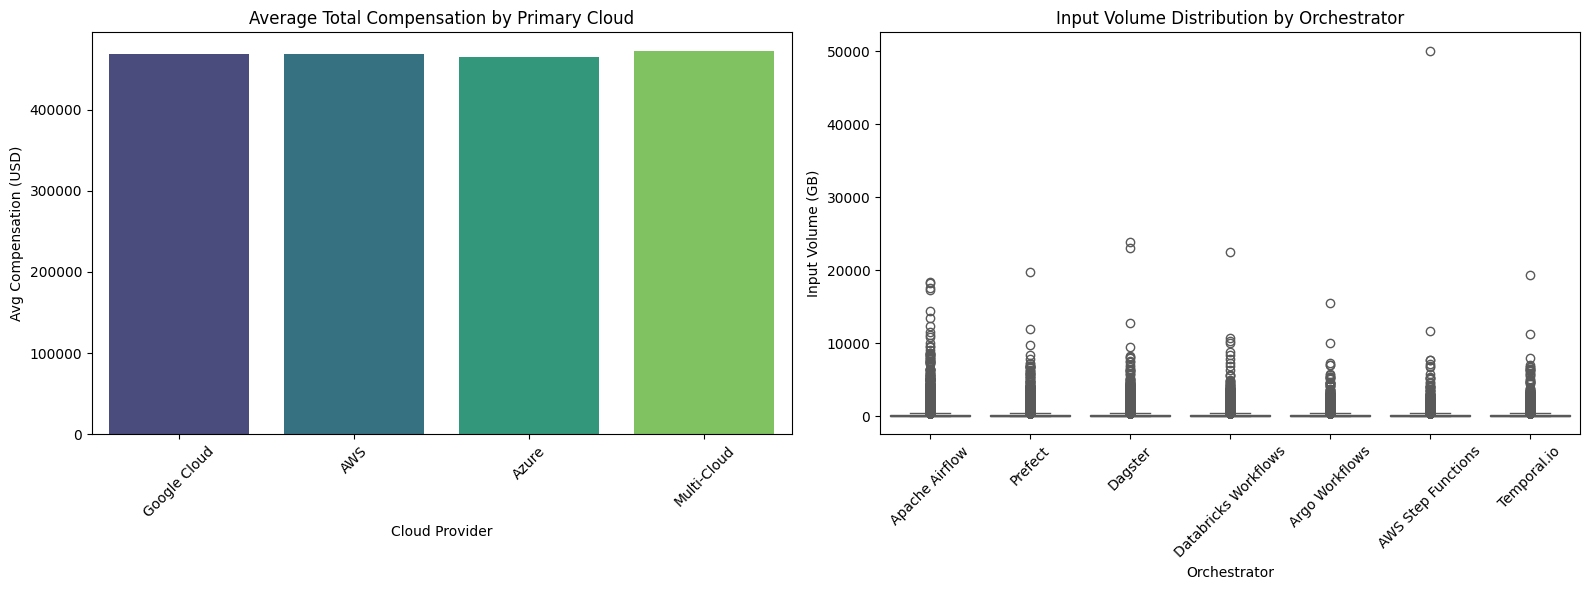

In [ ]:
# Create a new figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Compensation by Primary Cloud (using Master table) ---
# Assuming column names 'primary_cloud' and 'total_compensation_usd' exist based on dataset description
if 'primary_cloud' in df_master.columns and 'total_compensation_usd' in df_master.columns:
    sns.barplot(
        data=df_master,
        x='primary_cloud',
        y='total_compensation_usd',
        ax=axes[0],
        errorbar=None,
        palette='viridis'
    )
    axes[0].set_title('Average Total Compensation by Primary Cloud')
    axes[0].set_xlabel('Cloud Provider')
    axes[0].set_ylabel('Avg Compensation (USD)')
    axes[0].tick_params(axis='x', rotation=45)

# --- Plot 2: Input Volume by Orchestrator (using Telemetry table) ---
# Assuming column names 'orchestrator' and 'input_volume_gb' exist
if 'orchestrator' in df_telemetry.columns and 'input_volume_gb' in df_telemetry.columns:
    sns.boxplot(
        data=df_telemetry,
        x='orchestrator',
        y='input_volume_gb',
        ax=axes[1],
        palette='Set2'
    )
    axes[1].set_title('Input Volume Distribution by Orchestrator')
    axes[1].set_xlabel('Orchestrator')
    axes[1].set_ylabel('Input Volume (GB)')
    axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

✅ Columns successfully found -> Engine: 'execution_engine', Cost: 'infrastructure_cost_usd', Input Volume: 'input_volume_gb'

--- Average Cost per GB by Data Engine ($) ---
execution_engine
DuckDB (In-Process)            0.110693
Trino Distributed SQL          0.111108
Snowflake Virtual Warehouse    0.111885
Databricks Photon Engine       0.112757
Apache Flink 1.19              0.114529
BigQuery Serverless SQL        0.115066
Apache Spark 3.5 (EMR)         0.117140
Name: cost_per_gb, dtype: float64


/tmp/ipykernel_2084/1286620567.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cost_summary.index, y=cost_summary.values, palette='coolwarm')


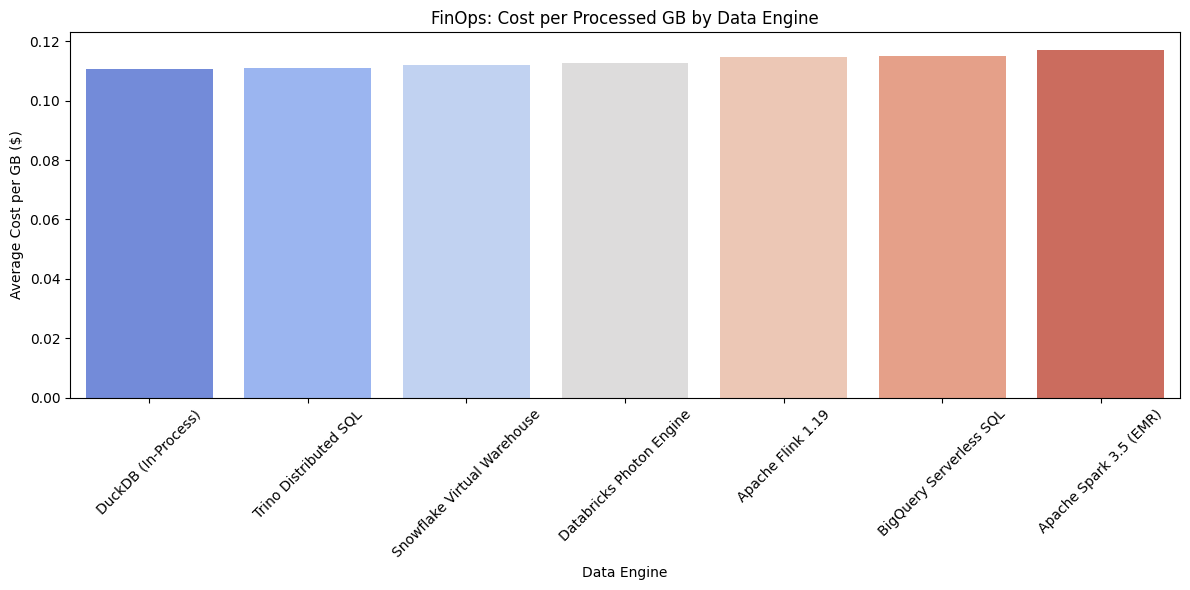

In [ ]:
# 1. Automatically find the correct column names based on keywords
try:
    engine_col = [col for col in df_telemetry.columns if 'engine' in col.lower()][0]
    cost_col = [col for col in df_telemetry.columns if 'cost' in col.lower()][0]
    input_col = [col for col in df_telemetry.columns if 'input' in col.lower()][0]

    print(f"✅ Columns successfully found -> Engine: '{engine_col}', Cost: '{cost_col}', Input Volume: '{input_col}'\n")

    # 2. Pandas ka use karke 'Cost per GB' calculate karna
    df_telemetry['cost_per_gb'] = df_telemetry[cost_col] / df_telemetry[input_col]

    # 3. Engine ke hisaab se average cost nikalna
    cost_summary = df_telemetry.groupby(engine_col)['cost_per_gb'].mean().sort_values()

    print("--- Average Cost per GB by Data Engine ($) ---")
    print(cost_summary)

    # 4. Is cost ko visualize karna
    plt.figure(figsize=(12, 6))
    sns.barplot(x=cost_summary.index, y=cost_summary.values, palette='coolwarm')
    plt.title('FinOps: Cost per Processed GB by Data Engine')
    plt.xlabel('Data Engine')
    plt.ylabel('Average Cost per GB ($)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

except IndexError:
    print("❌ Error: Automatic detection fail ho gaya. Kripya dataset ke saare columns ek baar print karein: print(df_telemetry.columns)")

In [ ]:
# Import libraries and reload only the required dataset to save RAM
import pandas as pd

telemetry_path = '/content/pipeline_execution_telemetry[1].parquet'
df_telemetry = pd.read_parquet(telemetry_path)

print(f"✅ Data Reloaded Successfully! Telemetry Records: {df_telemetry.shape}")

✅ Data Reloaded Successfully! Telemetry Records: (150000, 24)


Libraries for ML imported successfully!

Target Column (What we are predicting): 'failed_task_count'
Features (What we are using to predict): ['retry_attempts', 'input_volume_gb', 'output_volume_gb', 'infrastructure_cost_usd']

Training the Machine Learning model... (Please wait)

✅ --- Model Trained Successfully! ---
Model Accuracy: 75.37%



/tmp/ipykernel_5746/2867918189.py:55: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=features, palette='viridis')


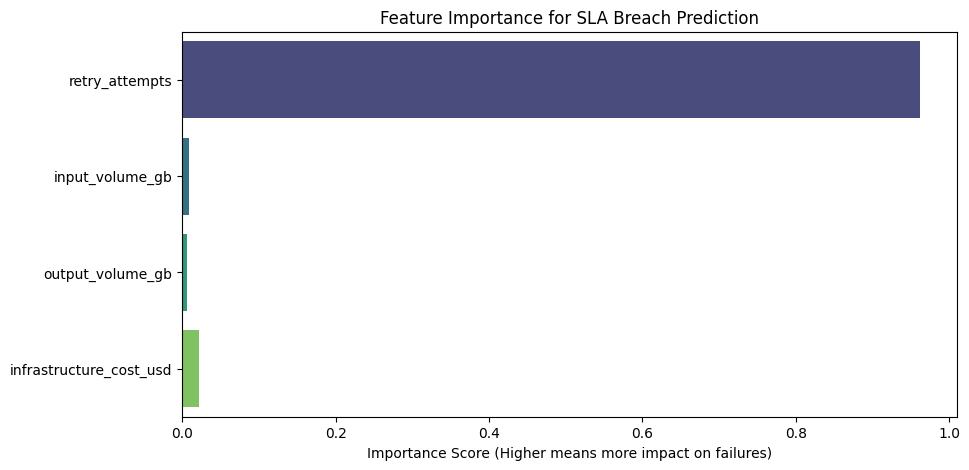

In [ ]:
# Import necessary libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries for ML imported successfully!\n")

try:
    # 1. Find the correct target column (looking for 'breach' instead of just 'sla')
    target_cols = [col for col in df_telemetry.columns if 'breach' in col.lower() or 'fail' in col.lower()]

    if len(target_cols) > 0:
        target_col = target_cols[0]
    else:
        print("Could not find a 'breach' column automatically. Printing all columns for manual check:")
        print(df_telemetry.columns.tolist())
        target_col = None

    if target_col:
        # 2. Select numerical features for prediction
        features = [col for col in df_telemetry.columns if 'volume' in col.lower() or 'cost' in col.lower() or 'retry' in col.lower()]

        print(f"Target Column (What we are predicting): '{target_col}'")
        print(f"Features (What we are using to predict): {features}\n")

        # 3. Data Preparation
        # Drop missing values to avoid errors during training
        ml_data = df_telemetry[features + [target_col]].dropna()

        X = ml_data[features]
        # Convert target to integer (0 or 1) for classification
        y = ml_data[target_col].astype(int)

        # 4. Train-Test Split (80% for training, 20% for testing)
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

        # 5. Model Training
        print("Training the Machine Learning model... (Please wait)")
        # Limit max_depth to prevent the model from taking too long or overfitting
        rf_model = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
        rf_model.fit(X_train, y_train)

        # 6. Prediction and Evaluation
        predictions = rf_model.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)

        print("\n✅ --- Model Trained Successfully! ---")
        print(f"Model Accuracy: {accuracy * 100:.2f}%\n")

        # 7. Display Feature Importance Visualization
        importances = rf_model.feature_importances_
        plt.figure(figsize=(10, 5))
        sns.barplot(x=importances, y=features, palette='viridis')
        plt.title('Feature Importance for SLA Breach Prediction')
        plt.xlabel('Importance Score (Higher means more impact on failures)')
        plt.show()

except Exception as e:
    print(f"❌ An error occurred: {e}")

✅ Survey data loaded successfully!

Analyzing how 'mlops_maturity_level' impacts 'base_salary_usd'...



/tmp/ipykernel_5746/2848224318.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_salary.index, y=avg_salary.values, palette='magma')


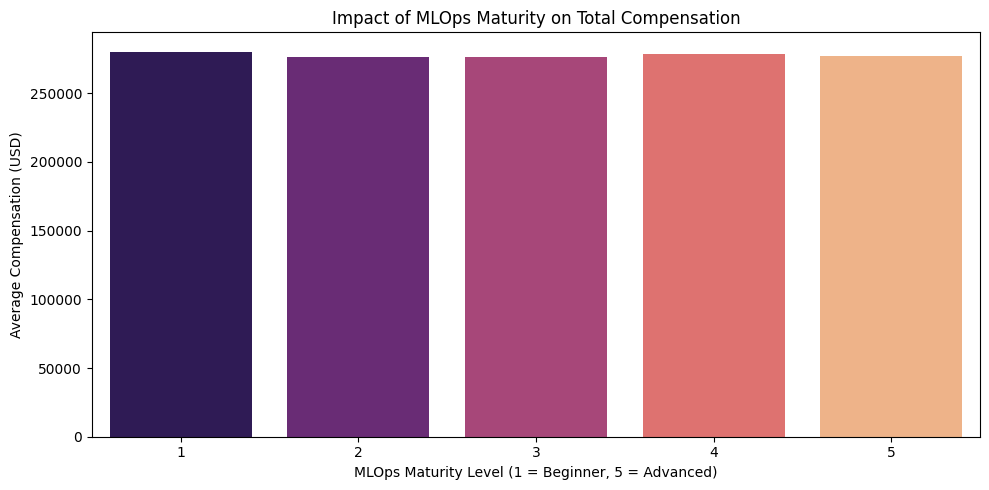

In [ ]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

survey_path = '/content/data_engineering_compensation_and_stack_survey[1].parquet'

try:
    # 1. Load the survey data
    df_survey = pd.read_parquet(survey_path)
    print("✅ Survey data loaded successfully!\n")

    # 2. Smartly detect columns for MLOps and Compensation
    maturity_col = [col for col in df_survey.columns if 'mlops' in col.lower() or 'maturity' in col.lower()][0]
    salary_col = [col for col in df_survey.columns if 'compensation' in col.lower() or 'salary' in col.lower()][0]

    print(f"Analyzing how '{maturity_col}' impacts '{salary_col}'...\n")

    # 3. Calculate average salary by MLOps maturity level
    avg_salary = df_survey.groupby(maturity_col)[salary_col].mean().sort_index()

    # 4. Visualize the results
    plt.figure(figsize=(10, 5))
    sns.barplot(x=avg_salary.index, y=avg_salary.values, palette='magma')
    plt.title('Impact of MLOps Maturity on Total Compensation')
    plt.xlabel('MLOps Maturity Level (1 = Beginner, 5 = Advanced)')
    plt.ylabel('Average Compensation (USD)')
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"❌ An error occurred: {e}")